# My Final Project 

Authors: Lynx Coleman

Imports the needed Packages as normal

In [ ]:
import numpy as np 
import sep 
import astropy.io.fits as fits 
import os
import matplotlib.pyplot as plt
from matplotlib import rcParams

from matplotlib.patches import Ellipse

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

Imports tthe Datta and defines and displays the background

0.0
0.0005398219218477607


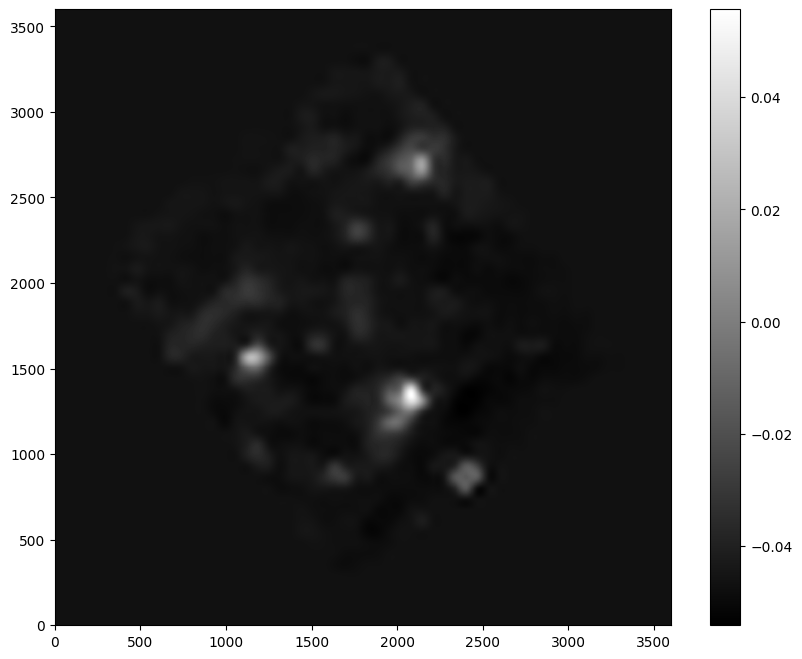

In [ ]:
path = r'C:\Users\jacal\Downloads\hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits' 

hdul = fits.getdata(path)

# show the image

data = hdul
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()

data = data.astype(data.dtype.newbyteorder('='))

bkg = sep.Background(data)

# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()

plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')


Subtracts the background from the data

In [ ]:
data_sub = data - bkg

Finds objects and displays how many there are with and adjustable threshold

In [19]:
objects = sep.extract(data_sub, 30.5, err=bkg.globalrms)
len(objects)

694

Displays the objects

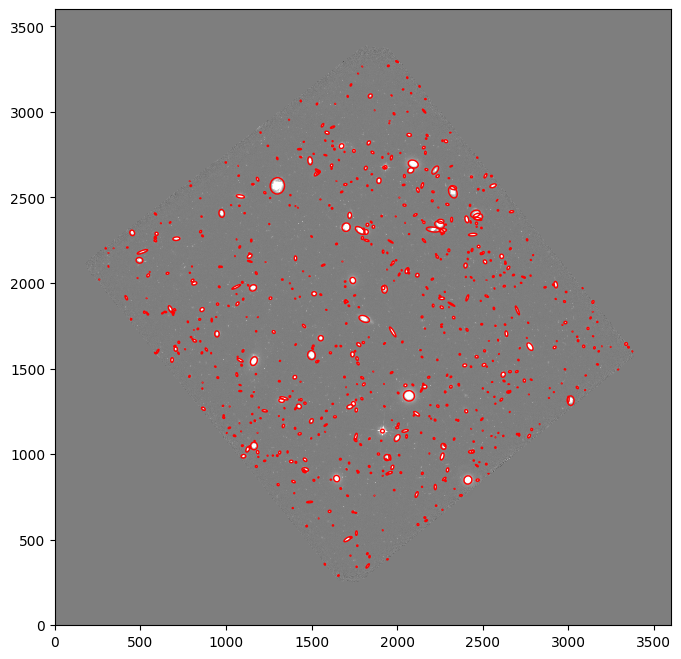

In [14]:
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

Finds the Flux of the objects

In [20]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

Prints out the Frist 100 Objects to get an idea of their fluxes

In [17]:
# show the first 10 objects results:
for i in range(100):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 1.152732 +/- 1.073658
object 1: flux = 0.553516 +/- 0.743992
object 2: flux = 1.119472 +/- 1.058055
object 3: flux = 0.875477 +/- 0.935674
object 4: flux = 0.687839 +/- 0.829365
object 5: flux = 0.759489 +/- 0.871491
object 6: flux = 0.496439 +/- 0.704590
object 7: flux = 1.255329 +/- 1.120418
object 8: flux = 0.973171 +/- 0.986499
object 9: flux = 3.196995 +/- 1.788017
object 10: flux = 0.863982 +/- 0.929511
object 11: flux = 1.054161 +/- 1.026727
object 12: flux = 0.416212 +/- 0.645151
object 13: flux = 1.421722 +/- 1.192363
object 14: flux = 0.673850 +/- 0.820889
object 15: flux = 2.254173 +/- 1.501393
object 16: flux = 1.209973 +/- 1.099991
object 17: flux = 0.416973 +/- 0.645741
object 18: flux = 0.799392 +/- 0.894092
object 19: flux = 0.535045 +/- 0.731473
object 20: flux = 8.199943 +/- 2.863556
object 21: flux = 1.301314 +/- 1.140755
object 22: flux = 0.446875 +/- 0.668493
object 23: flux = 0.514876 +/- 0.717554
object 24: flux = 0.769250 +/- 0.877073
object 25:

Rejects outliers and histrograms the fluxes and prints data

Std Flux Post Rejection:  32.33449191058063
mean Flux Post Rejection:  4.006326637604437
Number of Sources Post Rejection:  694
Largest outlier Pre Rejection is 805.4483374777567 away from mean


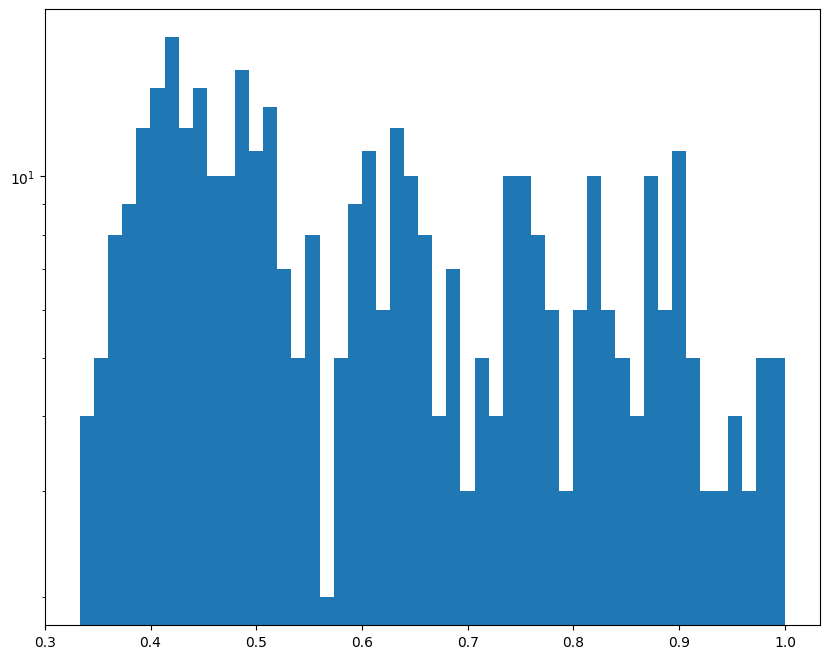

In [29]:
std_flux = np.std(flux)
mean_flux = np.mean(flux)

# plt.hist(flux)
# plt.plot(flux)

n_flux = []
for i in flux:
    if 0 < i < 1:
        n_flux.append(i)
n_flux = np.array(n_flux)
plt.hist(n_flux, bins=50)
plt.yscale("log")



print("Std Flux Post Rejection: ", std_flux)
print("mean Flux Post Rejection: ", mean_flux)
print("Number of Sources Post Rejection: ", len(flux))

z = np.max(flux) - mean_flux / std_flux
print(f"Largest outlier Pre Rejection is {z} away from mean")